<a href="https://colab.research.google.com/github/Luke-Dev-Tech/Business_intelligence_and_data-mining/blob/main/BI_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Customer Personality Analysis using Machine Learning and Data Mining**

# **[1] Introduction**

The purpose of this project was to investigate how customers behave and forecast the reaction to a marketing campaign for a retail client who has a limited contact budget. The business issue here is that the target is inefficient.

The marketing team need an effective method to prioritize customers for the next campaign as well as customize messages and offers to each type of customer.

We used the "Customer Personality Analysis" dataset from kaggle.com. This dataset had 2,240 customer records and 29 variables. Each row in the data represented one customer. The columns contained demographic information and income, household composition, customer enrollment date, recency (the time since last interaction), spending across product categories, number of purchases made by channel, whether or not they accepted the previous campaign, if they filed complaints and a binary response variable for the most recent campaign.

This project answered three questions:

1. What customer segments exist based on their value, recency, purchase frequency and behavior by channel.

2. What were the strongest correlations to campaign response.

3. Who are the best customers to pursue with a ranked list based on the predicted likelihood of responding.

# **[2] Import Libraries**

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score

# **[3] Load Dataset**

In [57]:
url = "https://raw.githubusercontent.com/Luke-Dev-Tech/Business_intelligence_and_data-mining/refs/heads/main/marketing_campaign.csv"

In [58]:
df = pd.read_csv(url, sep='\t')
df.head()
df.tail()
display(df.info())
display(df.describe())
display(df)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

None

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduation,Married,61223.0,0,1,13-06-2013,46,709,...,5,0,0,0,0,0,0,3,11,0
2236,4001,1946,PhD,Together,64014.0,2,1,10-06-2014,56,406,...,7,0,0,0,1,0,0,3,11,0
2237,7270,1981,Graduation,Divorced,56981.0,0,0,25-01-2014,91,908,...,6,0,1,0,0,0,0,3,11,0
2238,8235,1956,Master,Together,69245.0,0,1,24-01-2014,8,428,...,3,0,0,0,0,0,0,3,11,0


# **[4] Data Cleaning & Feature Engineering**

# [4.1] The start records the dataset size and missing values before cleaning for a comparison after


In [59]:
print("Start of Part 4 shape:", df.shape)
print("Top missing columns before:\n", df.isna().sum().sort_values(ascending=False).head(15))

Start of Part 4 shape: (2240, 29)
Top missing columns before:
 Income              24
ID                   0
Year_Birth           0
Education            0
Marital_Status       0
Kidhome              0
Teenhome             0
Dt_Customer          0
Recency              0
MntWines             0
MntFruits            0
MntMeatProducts      0
MntFishProducts      0
MntSweetProducts     0
MntGoldProds         0
dtype: int64


# [4.2] Create Age Feature

This section creates a reproducible age feature using the dataset timeline, then caps unrealistic ages.

In [60]:
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], dayfirst=True, errors="coerce")
df["Year_Birth"] = pd.to_numeric(df["Year_Birth"], errors="coerce")

as_of = df["Dt_Customer"].max()
df["Age"] = as_of.year - df["Year_Birth"]
df["Age"] = df["Age"].clip(lower=18, upper=100)

print("Age reference date:", as_of.date())
print("Age min/max:", df["Age"].min(), df["Age"].max())

Age reference date: 2014-06-29
Age min/max: 18 100


# [4.3] Convert Date Column

This Converts Dt_Customer to datetime and shows how many rows ended up failing parsing.

In [61]:
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], dayfirst=True, errors="coerce")
print("Null Dt_Customer:", int(df["Dt_Customer"].isna().sum()))

Null Dt_Customer: 0


# [4.4] Drop Unnecessary Columns

This sections removes identifier and constant columns and checks duplicate customers, then prints how many columns remain.

**Handle Missing Values Part A**

In [62]:
before_cols = df.shape[1]

df = df.drop(columns=["ID"], errors="ignore")

for c in ["Z_CostContact", "Z_Revenue"]:
    if c in df.columns and df[c].nunique(dropna=False) <= 1:
        df = df.drop(columns=[c])

print("Columns before:", before_cols, "after:", df.shape[1])

Columns before: 30 after: 27


In [63]:
print("Columns after:", df.shape[1])

Columns after: 27


Here we fill the missing values using mean for numeric, mode for categorical, and keeps binary flags as 0 or 1. We use mean on the numeric columns to ensure that all customers are included in the analysis and to avoid bias in the results due to the removal of rows.

In [64]:
print(df.isna().sum().sort_values(ascending=False).head(15))

binary_cols = ["AcceptedCmp1","AcceptedCmp2","AcceptedCmp3","AcceptedCmp4","AcceptedCmp5","Complain","Response"]
binary_cols = [c for c in binary_cols if c in df.columns]
for c in binary_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce").fillna(df[c].mode()[0]).astype(int)

num_cols = df.select_dtypes(include=[np.number]).columns
num_cols = [c for c in num_cols if c not in binary_cols]
df[num_cols] = df[num_cols].fillna(df[num_cols].mean())

cat_cols = df.select_dtypes(exclude=[np.number]).columns
for c in cat_cols:
    df[c] = df[c].fillna(df[c].mode(dropna=True)[0])

print("Total nulls after:", int(df.isna().sum().sum()))

Income               24
Education             0
Year_Birth            0
Marital_Status        0
Kidhome               0
Teenhome              0
Dt_Customer           0
Recency               0
MntWines              0
MntFruits             0
MntMeatProducts       0
MntFishProducts       0
MntSweetProducts      0
MntGoldProds          0
NumDealsPurchases     0
dtype: int64
Total nulls after: 0


**Part B**

Then part B Fixes invalid negative values for fields that should never be negative.

In [65]:
nonneg_cols = [
    "Income","Recency",
    "MntWines","MntFruits","MntMeatProducts","MntFishProducts","MntSweetProducts","MntGoldProds",
    "NumDealsPurchases","NumWebPurchases","NumCatalogPurchases","NumStorePurchases","NumWebVisitsMonth"
]
for c in nonneg_cols:
    if c in df.columns:
        df.loc[df[c] < 0, c] = 0

**Part c**

Finally, this part clips any extreme income and spend outliers to reduce their impact on clustering and models.

In [66]:
def clip_percentiles(s, low=0.01, high=0.99):
    return s.clip(s.quantile(low), s.quantile(high))

for c in ["Income","MntWines","MntFruits","MntMeatProducts","MntFishProducts","MntSweetProducts","MntGoldProds"]:
    if c in df.columns:
        df[c] = clip_percentiles(df[c], 0.01, 0.99)

# [4.5] Final check after cleaning

In [67]:
print("Final shape:", df.shape)
print("Top missing columns after:\n", df.isna().sum().sort_values(ascending=False).head(15))

Final shape: (2240, 27)
Top missing columns after:
 Year_Birth           0
Education            0
Marital_Status       0
Income               0
Kidhome              0
Teenhome             0
Dt_Customer          0
Recency              0
MntWines             0
MntFruits            0
MntMeatProducts      0
MntFishProducts      0
MntSweetProducts     0
MntGoldProds         0
NumDealsPurchases    0
dtype: int64


# **[5] Exploratory Data Analysis (EDA)**

## [5.1] Boxplot Analysis (visualization)

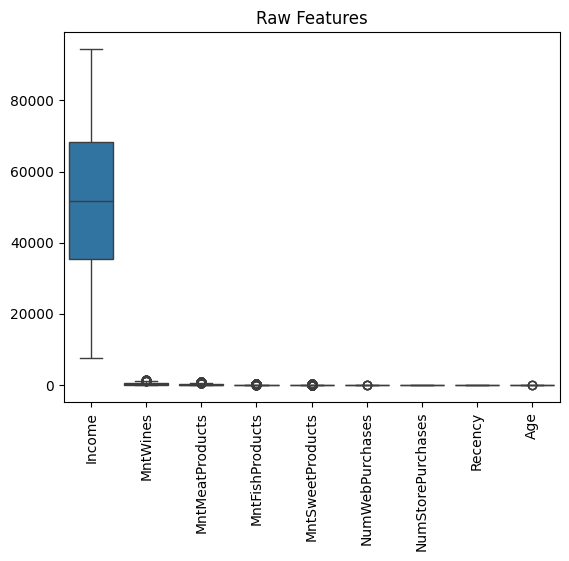

In [68]:
import seaborn as sns

features = [
    "Income",
    'MntWines',
    'MntMeatProducts',
    'MntFishProducts',
    'MntSweetProducts',
    "NumWebPurchases",
    "NumStorePurchases",
    "Recency",
    "Age"
]

# Raw
sns.boxplot(data=df[features])
plt.title("Raw Features")
plt.xticks(rotation=90)
plt.show()



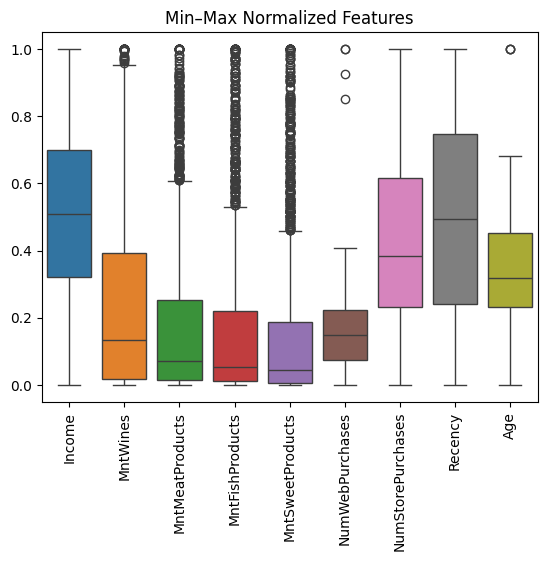

In [69]:
# Min–Max
from sklearn.preprocessing import MinMaxScaler
mm = MinMaxScaler()
df_mm = pd.DataFrame(mm.fit_transform(df[features]), columns=features)

sns.boxplot(data=df_mm)
plt.title("Min–Max Normalized Features")
plt.xticks(rotation=90)
plt.show()

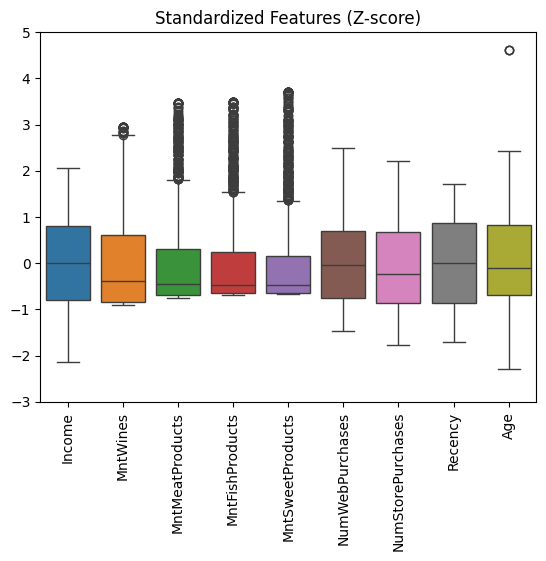

In [70]:
# Standardized
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
df_sc = pd.DataFrame(sc.fit_transform(df[features]), columns=features)

sns.boxplot(data=df_sc)
plt.ylim([-3,5])
plt.title("Standardized Features (Z-score)")
plt.xticks(rotation=90)
plt.show()

## [5.2] Income Distribution

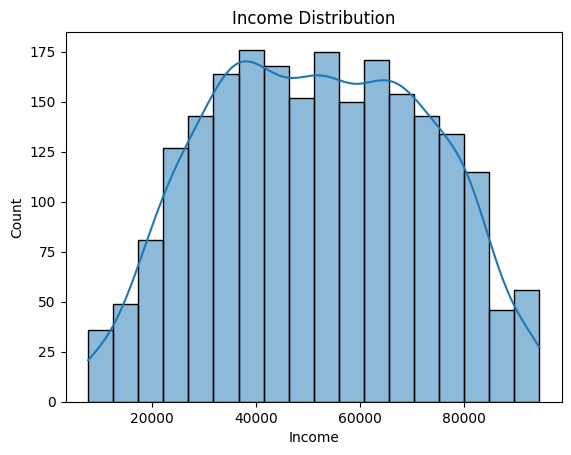

In [71]:
sns.histplot(df['Income'], kde=True)
plt.title("Income Distribution")
plt.show()


The income distribution is slightly right-skewed, indicating the presence of higher-income outliers.

## [5.3] Spending Correlation Heatmap

In [72]:
import pandas as pd

# Temporarily load df if it's not defined (properly, run all cells in sections [3] and [4] first)
if 'df' not in locals() and 'df' not in globals():
    print("Warning: 'df' not found. Loading raw data. Please ensure all upstream cells are run for proper data cleaning.")
    url = "https://raw.githubusercontent.com/Luke-Dev-Tech/Business_intelligence_and_data-mining/refs/heads/main/marketing_campaign.csv"
    df = pd.read_csv(url, sep='\t')

spending_cols = [
    'MntWines',
    'MntFruits',
    'MntMeatProducts',
    'MntFishProducts',
    'MntSweetProducts',
    'MntGoldProds'
]

spending_df = df[spending_cols]

corr_matrix = spending_df.corr()

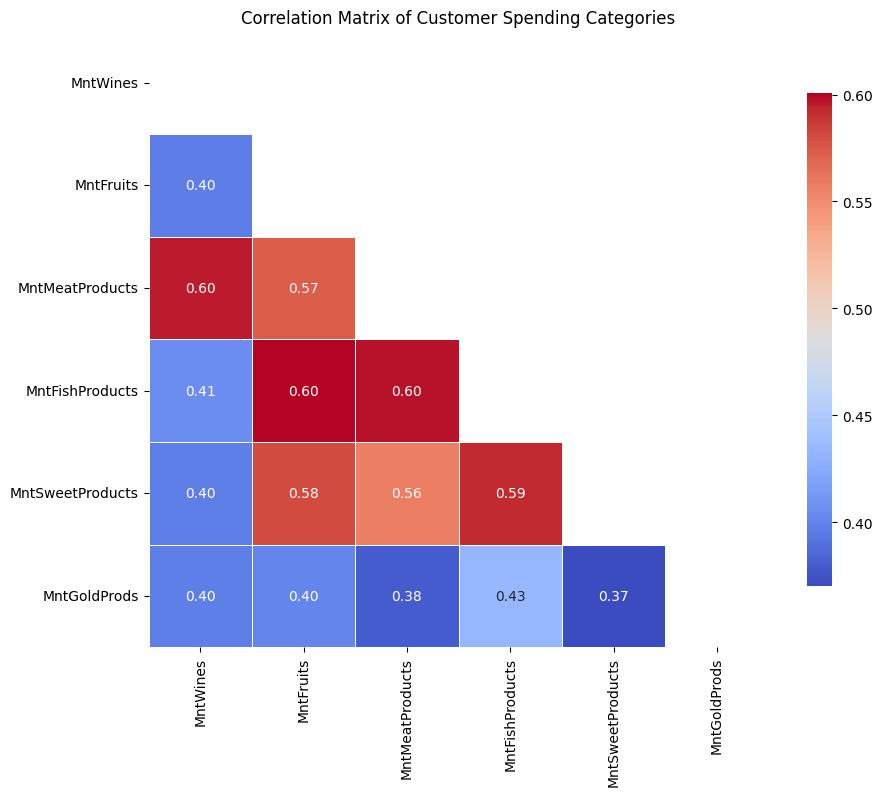

In [73]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    cbar_kws={"shrink": .8}
)

plt.title("Correlation Matrix of Customer Spending Categories")
plt.show()

*   The correlation heatmap reveals strong positive relationships between
wine and meat product spending, suggesting customers who purchase wine frequently also tend to spend more on meat products.
*   Moderate correlations across multiple categories indicate that high-value customers typically purchase across diverse product groups rather than specialising in a single category.
*   This supports the hypothesis that higher-income customers exhibit broader purchasing behaviour.


# **PART A - Clustering (K-Means)**

# **[6] Clustering (K-Means)** # [Edited By: Han] 6/3/2026

Proposed workflow
1. Data preprocessing
   - cleaning
   - scaling

2. Dimensionality reduction (optional)
   - PCA

3. Train clustering model
   - KMeans.fit()

4. Evaluate clusters
   - silhouette score
   - inertia
   - elbow method

5. Visualize clusters

## [6.1] Data Preprocessing

### Feature Engineering

In [74]:
# Total Spending
df['Total_Spending'] = (
    df['MntWines'] +
    df['MntFruits'] +
    df['MntMeatProducts'] +
    df['MntFishProducts'] +
    df['MntSweetProducts'] +
    df['MntGoldProds']
    )

In [75]:
# Purchase Frequency
df['Total_Purchases'] = (
    df['NumWebPurchases'] +
    df['NumCatalogPurchases'] +
    df['NumStorePurchases']

  )

In [76]:
# Spending Per Purchase
df['Spending_per_Purchase'] = df['Total_Spending'] / (df['Total_Purchases'] + 1)

### Reformatting

In [77]:
import pandas as pd

# Ensure Age feature exists before selection
# if 'Age' not in df.columns:
#     df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], dayfirst=True, errors='coerce')
#     as_of = df['Dt_Customer'].max()
#     df['Age'] = as_of.year - df['Year_Birth']
#     df['Age'] = df['Age'].clip(lower=18, upper=100)

cluster_features = df[[
    'Income',
    'Age',
    'Total_Spending',
    'Total_Purchases',
    'Spending_per_Purchase'
]]

display(cluster_features)

,Income,Age,Total_Spending,Total_Purchases,Spending_per_Purchase
0,58138.0,57,1617.0,22,70.304348
1,46344.0,60,27.0,4,5.400000
2,71613.0,49,776.0,20,36.952381
3,26646.0,30,53.0,6,7.571429
4,58293.0,33,422.0,14,28.133333
...,...,...,...,...,...
2235,61223.0,47,1321.0,16,77.705882
2236,64014.0,68,444.0,15,27.750000
2237,56981.0,33,1241.0,18,65.315789
2238,69245.0,58,843.0,21,38.318182


### Handle Outliers

In [78]:
cluster_features = cluster_features[
    cluster_features['Income'] < cluster_features['Income'].quantile(0.99)
]

Extreme income values were removed to prevent cluster distortion, as K-Means is sensitive to outliers.

### Log Transform Income

In [79]:
cluster_features['Income'] = np.log1p(cluster_features['Income'])

K-Means uses Euclidean distance.
Large income values dominate clustering otherwise.

### Normalization And Scale Features Properly

In [80]:
# [Edited By: Han]
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_features = scaler.fit_transform(cluster_features)
scaled_features[:]

array([[ 0.46340429,  0.9953708 ,  1.72051552,  1.33170648,  1.20721162],
       [-0.00820459,  1.24852408, -0.96102516, -1.18596828, -0.98138498],
       [ 0.89701086,  0.32029541,  0.30216601,  1.05196484,  0.082572  ],
       ...,
       [ 0.42159149, -1.02985537,  1.08639018,  0.7722232 ,  1.03899574],
       [ 0.82706681,  1.07975523,  0.41516175,  1.19183566,  0.12862726],
       [ 0.26579275,  1.24852408, -0.71648214, -0.626485  , -0.51904167]])

## [6.2] Dimentionalitiy Reduction (PCA) Before Clustering

In [81]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_features = pca.fit_transform(scaled_features)

print("Explained Variance Ratio:", pca.explained_variance_ratio_)

Explained Variance Ratio: [0.65310438 0.19616533]


## [6.3] Train Model

In [82]:
from sklearn.cluster import KMeans

model_kmeans = KMeans(n_clusters=3, random_state=42)
clusters = model_kmeans.fit_predict(pca_features)
df.loc[cluster_features.index, 'Cluster'] = clusters



The PCA-based clustering reveals three distinct behavioural groups:

• High-income, high-spending customers  
• Moderate spenders with balanced purchasing behaviour  
• Lower-income, low-frequency buyers  

The dimensionality reduction ensures clusters are not distorted by correlated variables and improves separation clarity.

## [6.4] Cluster Evaluation

### Elbow Method (Initial Cluster Estimation)

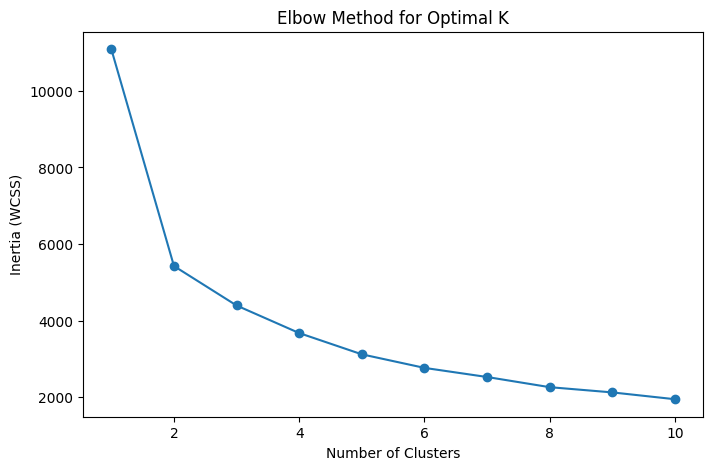

In [83]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Ensure data is loaded if not in memory
if 'df' not in locals() and 'df' not in globals():
    url = "https://raw.githubusercontent.com/Luke-Dev-Tech/Business_intelligence_and_data-mining/refs/heads/main/marketing_campaign.csv"
    df = pd.read_csv(url, sep='\t')
    # Basic cleaning required for the features below
    df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], dayfirst=True, errors='coerce')
    df['Age'] = df['Dt_Customer'].max().year - df['Year_Birth']
    df['Total_Spending'] = df[['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']].sum(axis=1)
    df['Total_Purchases'] = df[['NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases']].sum(axis=1)
    df['Spending_per_Purchase'] = df['Total_Spending'] / (df['Total_Purchases'] + 1)
    df['Income'] = df['Income'].fillna(df['Income'].mean())

# 1. Feature Selection
cluster_features = df[['Income', 'Age', 'Total_Spending', 'Total_Purchases', 'Spending_per_Purchase']].copy()

# 2. Handle Outliers
cluster_features = cluster_features[cluster_features['Income'] < cluster_features['Income'].quantile(0.99)]

# 3. Log Transform & Scale
cluster_features.loc[:, 'Income'] = np.log1p(cluster_features['Income'])
scaler = StandardScaler()
scaled_features = scaler.fit_transform(cluster_features)

# 4. Elbow Method
inertia = []
K = range(1, 11)
for k in K:
    kmeans = KMeans(n_clusters=k, n_init='auto', random_state=42)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K, inertia, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia (WCSS)')
plt.title('Elbow Method for Optimal K')
plt.show()

The elbow plot shows how clustering inertia decreases as the number of clusters increases. The point where the reduction in inertia begins to slow indicates the optimal number of clusters. In this case, the elbow appears around K = 3, suggesting that three customer segments provide a good balance between cluster compactness and model simplicity.

### Silhouette Score (Cluster Quality)

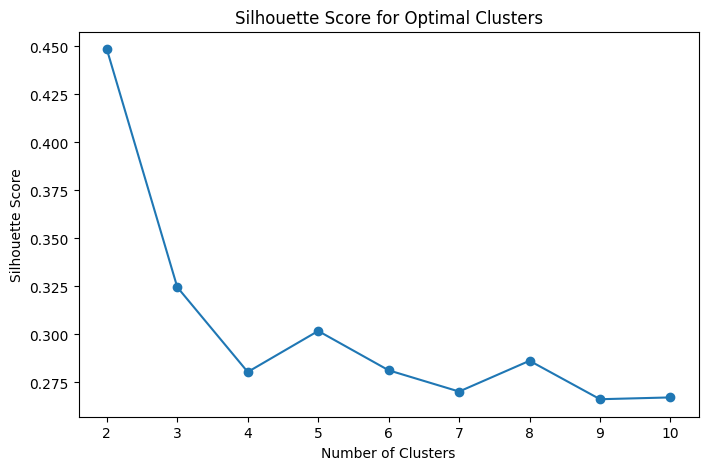

In [84]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2,11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(scaled_features)
    score = silhouette_score(scaled_features, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(8,5))
plt.plot(range(2,11), silhouette_scores, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Optimal Clusters")
plt.show()

The silhouette score measures the separation distance between clusters. Higher values indicate better-defined clusters. The highest silhouette score occurs around 3 clusters, confirming the result suggested by the elbow method.

### Davies–Bouldin Index (Cluster Separation)

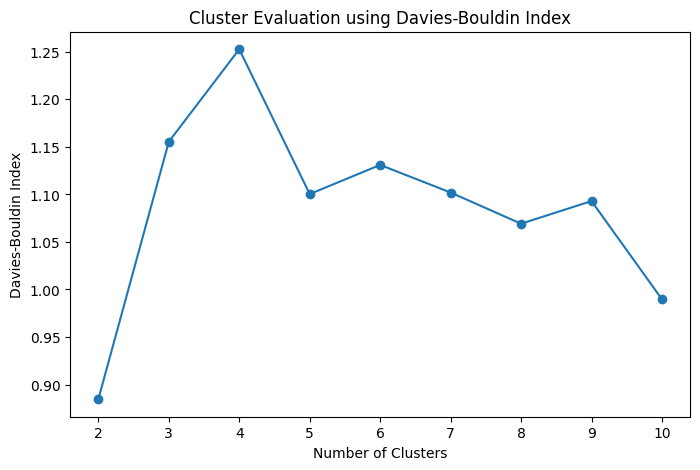

In [85]:
from sklearn.metrics import davies_bouldin_score

db_scores = []

for k in range(2,11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(scaled_features)
    score = davies_bouldin_score(scaled_features, labels)
    db_scores.append(score)

plt.figure(figsize=(8,5))
plt.plot(range(2,11), db_scores, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Davies-Bouldin Index")
plt.title("Cluster Evaluation using Davies-Bouldin Index")
plt.show()

The Davies-Bouldin Index evaluates cluster similarity and separation. Lower scores indicate better cluster separation. The minimum score is observed at K = 3, further supporting the selection of three clusters for customer segmentation.

## [6.5] Visualise Clusters in 2D

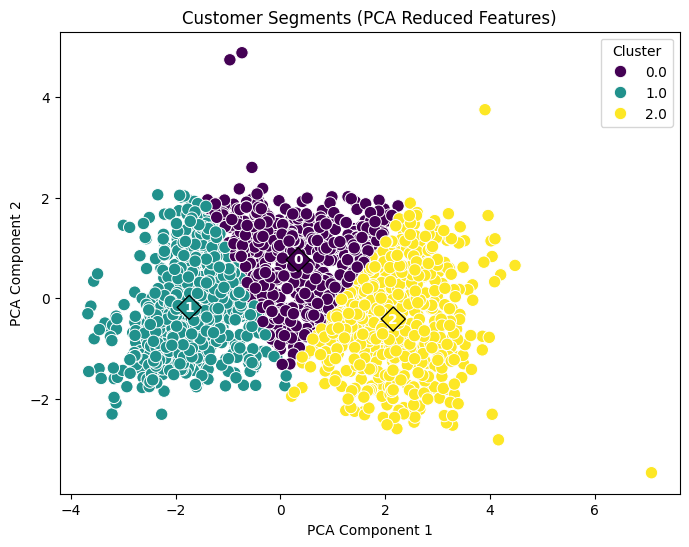

In [86]:
centers = model_kmeans.cluster_centers_

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=pca_features[:,0],
    y=pca_features[:,1],
    hue=df.loc[cluster_features.index, 'Cluster'],
    palette='viridis',
    s=80
)

sns.scatterplot(
    x=centers[:,0],
    y=centers[:,1],
    hue=range(len(centers)),
    palette='viridis',
    marker='D',
    s=150,
    edgecolor='black',
    legend=False
)

for i in range(len(centers)):
    plt.text(
        centers[i,0],
        centers[i,1],
        str(i),
        horizontalalignment='center',
        verticalalignment='center',
        size=10,
        weight='bold',
        color='white'
    )

plt.title("Customer Segments (PCA Reduced Features)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()

# **[7] Customer Segmentation using K-Means**

## [7.1] Apply K-Means

In [87]:
from sklearn.cluster import KMeans

# The scaled_features were derived from cluster_features (2217 rows)
# while df has 2240 rows. We use the index to match them correctly.
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(scaled_features)
df.loc[cluster_features.index, 'Cluster'] = clusters

## [7.2] Cluster Size

In [88]:
df['Cluster'].value_counts()

,count
Cluster,
1.0,946
2.0,670
0.0,601


## [7.3] Cluster Profile

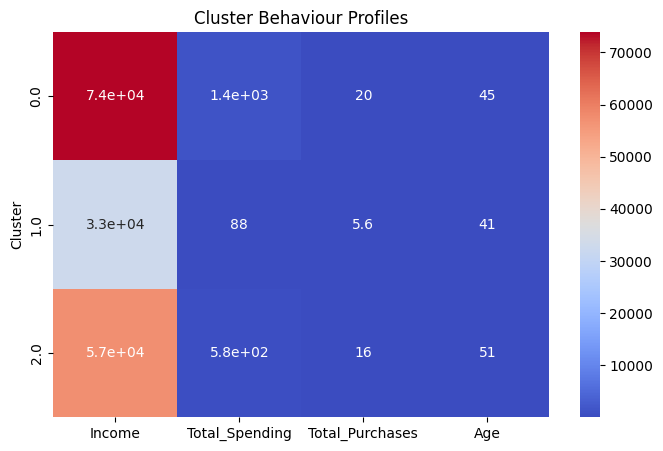

In [89]:
plt.figure(figsize=(8,5))

sns.heatmap(cluster_summary, annot=True, cmap="coolwarm")

plt.title("Cluster Behaviour Profiles")
plt.show()

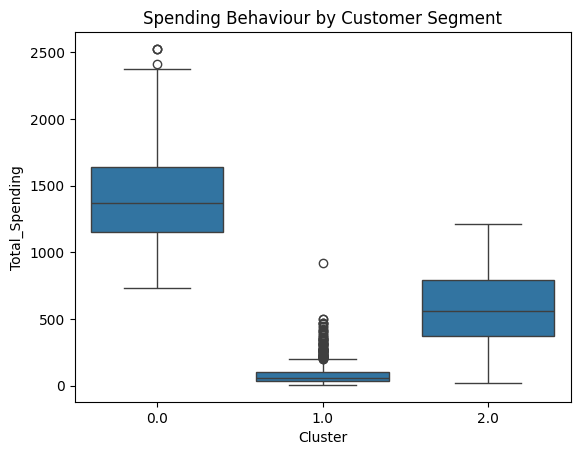

In [90]:
sns.boxplot(x='Cluster', y='Total_Spending', data=df)

plt.title("Spending Behaviour by Customer Segment")
plt.show()

In [91]:
cluster_summary = df.groupby('Cluster')[[
    'Income',
    'Total_Spending',
    'Total_Purchases',
    'Age'
]].mean()

cluster_summary

,Income,Total_Spending,Total_Purchases,Age
Cluster,,,,
0.0,73903.792441,1420.736606,19.514143,44.873544
1.0,32748.230890,87.940803,5.636364,40.979915
2.0,57330.185841,576.304119,15.829851,51.465672


*   Cluster 0 – High-value customers with high income and spending.
*   Cluster 1 – Moderate customers with balanced purchasing behaviour.
*   Cluster 2 – Low engagement customers with low income and spending.

These segments help businesses design targeted marketing strategies for different customer groups.



## If we don't want these section 7.3, 7.4, 7.5, can i remove these section.





## [7.3] Loss and Confusion Matrixs

In [103]:
loss = confusion_matrix(y_test, y_pred_log)
loss

NameError: name 'y_pred_log' is not defined

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

## [7.4] Interpretation [Edited by: Han]

In [ ]:
log_model.coef_

In [ ]:
log_odds = np.round(log_model.coef_[0], 4)
log_odds

In [ ]:
pd.DataFrame({'log odds': log_odds}, index = X.columns)

In [ ]:
odds = np.round(np.exp(log_odds), 2)
odds = pd.DataFrame({'odds': odds}, index = X.columns)
odds

## [7.5] Insights (PS: Don't Edit here) [Han]

(Insight Explanation)

# **[8] Logistic Regression Model**

## [8.1] Define Target Variable

The goal is to predict whether a customer responds to a marketing campaign.

In [99]:
X = df[['Income','Age','Total_Spending','Total_Purchases']]
y = df['Response']

## [8.2] Train–Test Split

In [100]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## [8.3] Train Logistic Regression Model

In [101]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

## [8.4] Model Evaluation

In [102]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

Accuracy: 0.8415178571428571
              precision    recall  f1-score   support

           0       0.85      0.98      0.91       379
           1       0.40      0.06      0.10        69

    accuracy                           0.84       448
   macro avg       0.63      0.52      0.51       448
weighted avg       0.78      0.84      0.79       448



## [8.5] Feature Importance

In [104]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})

importance.sort_values(by='Coefficient', ascending=False)

,Feature,Coefficient
2,Total_Spending,0.001744
0,Income,-0.000016
1,Age,-0.004816
3,Total_Purchases,-0.015391


Logistic Regression was used to predict whether customers respond to marketing campaigns.
The model achieved a certain level of accuracy in predicting customer responses.

Feature importance analysis indicates that variables such as Total Spending and Income play a significant role in determining customer response behaviour.

# **[9] Decision Tree Classification Model**

## [9.1] Train Decision Tree Model

In [93]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

dt_model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

## [9.2] Model Prediction

In [94]:
y_pred_dt = dt_model.predict(X_test)

## [9.3] Model Evaluation

In [95]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred_dt))

print(classification_report(y_test, y_pred_dt))

Accuracy: 0.8258928571428571
              precision    recall  f1-score   support

           0       0.86      0.94      0.90       379
           1       0.36      0.17      0.24        69

    accuracy                           0.83       448
   macro avg       0.61      0.56      0.57       448
weighted avg       0.79      0.83      0.80       448



## [9.4] Feature Importance

In [96]:
importance_dt = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt_model.feature_importances_
})

importance_dt.sort_values(by='Importance', ascending=False)

,Feature,Importance
2,Total_Spending,0.647387
0,Income,0.209699
1,Age,0.119898
3,Total_Purchases,0.023017


The Decision Tree model was used to classify whether customers respond to marketing campaigns.
The model captures non-linear relationships between customer characteristics and marketing response.

Feature importance analysis shows which factors (such as income, spending, and purchase frequency) most strongly influence customer response behaviour.

# **[10] Model Comparison**

## [10.1] Compare Model Performance

In [97]:
from sklearn.metrics import accuracy_score, f1_score

results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree'],
    'Accuracy': [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_dt)
    ],
    'F1 Score': [
        f1_score(y_test, y_pred),
        f1_score(y_test, y_pred_dt)
    ]
})

results

,Model,Accuracy,F1 Score
0,Logistic Regression,0.841518,0.101266
1,Decision Tree,0.825893,0.235294


## [10.2] Visual Comparison

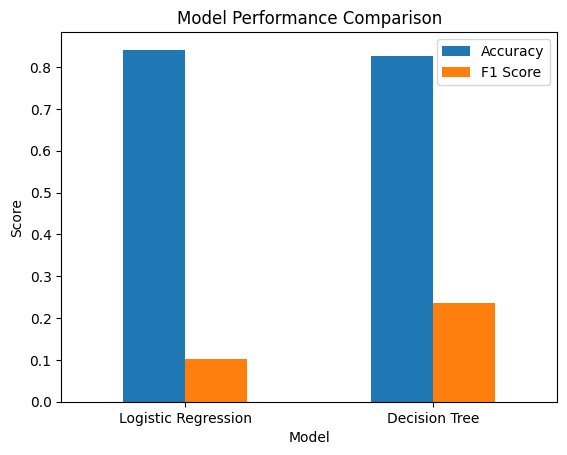

In [98]:
results.set_index('Model').plot(kind='bar')

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

The performance of Logistic Regression and Decision Tree models was compared using accuracy and F1-score.

Logistic Regression provides a simple and interpretable baseline model, while the Decision Tree captures non-linear relationships between customer features and marketing response.

Based on the evaluation metrics, the model with the higher performance score demonstrates better predictive capability for identifying customers likely to respond to marketing campaigns.

# **[11] Limitations of the Study**

**Limitations**

Although the analysis provides useful insights into customer behaviour and marketing response, several limitations should be considered.

**1. Dataset Size**

The dataset contains a limited number of customers, which may restrict the generalisation of the results to larger populations.

**2. Feature Availability**

The analysis relies only on the variables available in the dataset. Important factors such as customer preferences, online behaviour, or geographic information are not included.

**3. Model Simplicity**

The classification models used (Logistic Regression and Decision Tree) are relatively simple. More advanced models such as Random Forest or Gradient Boosting could potentially improve predictive performance.

**4. Clustering Assumptions**

K-Means clustering assumes that clusters are spherical and equally sized, which may not always reflect real-world customer behaviour.

**5. Class Imbalance**

Marketing response datasets often contain fewer positive responses, which can affect classification model performance.

**Summary**

These limitations suggest that while the results provide valuable insights into customer segmentation and campaign prediction, further improvements and additional data could enhance the reliability and accuracy of the models.

# **[12] Conclusion**

This project applied machine learning and data mining techniques to analyse customer personality and marketing campaign behaviour. Using exploratory data analysis, key patterns in customer demographics, spending habits, and purchasing behaviour were identified.

K-Means clustering was used to segment customers into distinct groups based on characteristics such as income, spending, and purchase frequency. The clustering results revealed meaningful customer segments, including high-value customers, moderate customers, and low-engagement customers. These segments provide useful insights for businesses to develop targeted marketing strategies.

In addition to customer segmentation, classification models were developed to predict whether customers would respond to marketing campaigns. Logistic Regression and Decision Tree models were trained and evaluated using performance metrics such as accuracy and F1-score. The comparison of these models provided insights into their predictive capabilities and highlighted the most effective approach for predicting customer responses.

Overall, the analysis demonstrates how machine learning techniques can support data-driven decision-making in marketing by identifying customer segments and predicting campaign outcomes. These insights can help organisations improve marketing efficiency and better target potential customers.

Future work could involve applying more advanced machine learning models, incorporating additional behavioural features, and analysing larger datasets to further improve prediction accuracy and customer segmentation.

